In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr

# Descargar datos del VIX y Bitcoin (BTC-USD)
vix = yf.download("^VIX", start="2020-01-01", end="2025-01-01")
btc = yf.download("BTC-USD", start="2020-01-01", end="2025-01-01")

# Mantener solo columnas de cierre
vix = vix[["Close"]].rename(columns={"Close": "VIX_Close"})
btc = btc[["Close"]].rename(columns={"Close": "BTC_Close"})


YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


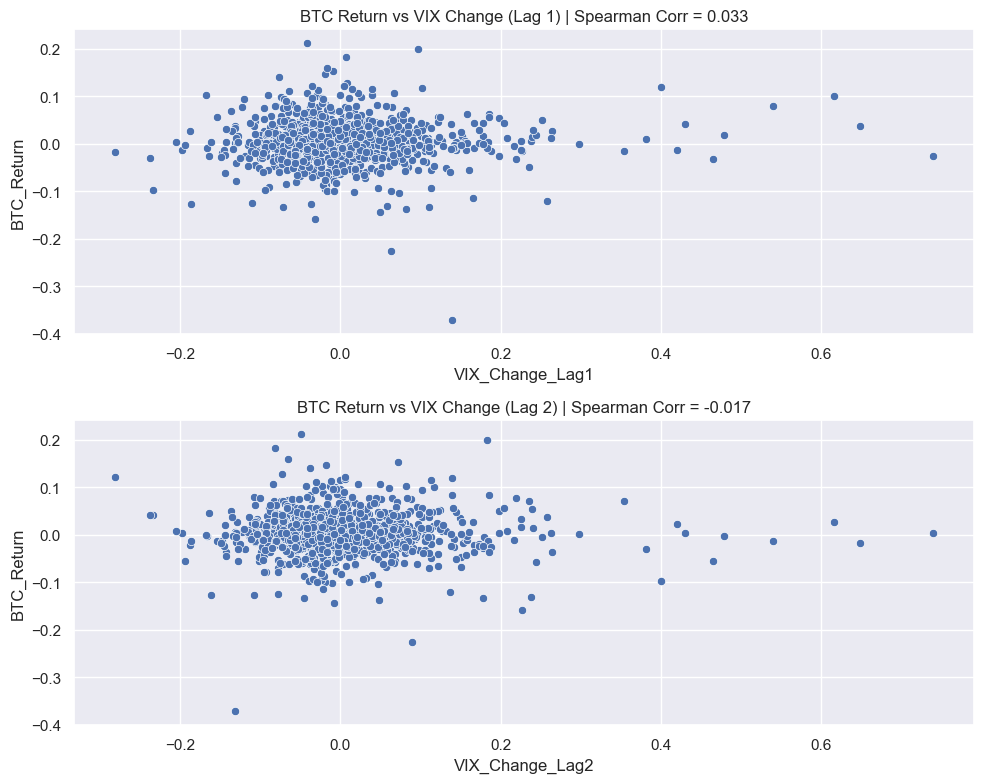

Correlación Spearman Lag 1: SignificanceResult(statistic=np.float64(0.03331146497432246), pvalue=np.float64(0.23830158699086976))
Correlación Spearman Lag 2: SignificanceResult(statistic=np.float64(-0.016947182444659276), pvalue=np.float64(0.5486292997061044))


In [2]:
# Unir ambos datasets
df = vix.join(btc, how="inner")

# Calcular retornos de BTC y cambios en VIX
df["BTC_Return"] = df["BTC_Close"].pct_change()
df["VIX_Change"] = df["VIX_Close"].pct_change()

# Lag de VIX
df["VIX_Change_Lag1"] = df["VIX_Change"].shift(1)
df["VIX_Change_Lag2"] = df["VIX_Change"].shift(2)

# Limpieza
df_clean = df.dropna()

# Correlaciones
corr_lag1 = spearmanr(df_clean["VIX_Change_Lag1"], df_clean["BTC_Return"])
corr_lag2 = spearmanr(df_clean["VIX_Change_Lag2"], df_clean["BTC_Return"])

# Visualización
sns.set(style="darkgrid")
fig, axs = plt.subplots(2, 1, figsize=(10, 8))

sns.scatterplot(x="VIX_Change_Lag1", y="BTC_Return", data=df_clean, ax=axs[0])
axs[0].set_title(f"BTC Return vs VIX Change (Lag 1) | Spearman Corr = {corr_lag1.correlation:.3f}")

sns.scatterplot(x="VIX_Change_Lag2", y="BTC_Return", data=df_clean, ax=axs[1])
axs[1].set_title(f"BTC Return vs VIX Change (Lag 2) | Spearman Corr = {corr_lag2.correlation:.3f}")

plt.tight_layout()
plt.show()

print("Correlación Spearman Lag 1:", corr_lag1)
print("Correlación Spearman Lag 2:", corr_lag2)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Cantidad de eventos detectados: 55

Resumen estadístico de BTC tras spikes del VIX:
Price  BTC_RETURN_24H BTC_RETURN_48H
Ticker                              
count       55.000000      55.000000
mean         0.009073       0.003172
std          0.041868       0.064502
min         -0.120876      -0.171652
25%         -0.010922      -0.022855
50%          0.006197      -0.000182
75%          0.028741       0.040236
max          0.119281       0.188308


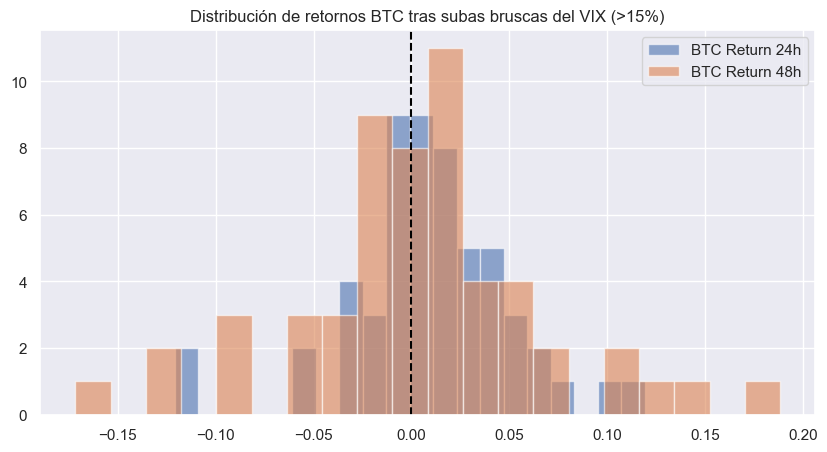

In [3]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Descargar datos
vix = yf.download("^VIX", start="2020-01-01", end="2025-01-01")[["Close"]].rename(columns={"Close": "VIX_Close"})
btc = yf.download("BTC-USD", start="2020-01-01", end="2025-01-01")[["Close"]].rename(columns={"Close": "BTC_Close"})

# Unir y calcular variaciones
df = vix.join(btc, how="inner")
df["VIX_PCT_CHANGE"] = df["VIX_Close"].pct_change()
df["BTC_RETURN_24H"] = df["BTC_Close"].pct_change().shift(-1)
df["BTC_RETURN_48H"] = (df["BTC_Close"].shift(-2) - df["BTC_Close"]) / df["BTC_Close"]

# Definir eventos de spike de VIX > 15%
event_mask = df["VIX_PCT_CHANGE"] > 0.15
event_df = df[event_mask][["VIX_PCT_CHANGE", "BTC_RETURN_24H", "BTC_RETURN_48H"]]

# Estadísticas
summary = event_df[["BTC_RETURN_24H", "BTC_RETURN_48H"]].describe()

# Mostrar eventos
print(f"Cantidad de eventos detectados: {len(event_df)}")
print("\nResumen estadístico de BTC tras spikes del VIX:")
print(summary)

# Visualización
plt.figure(figsize=(10,5))
plt.hist(event_df["BTC_RETURN_24H"], bins=20, alpha=0.6, label="BTC Return 24h")
plt.hist(event_df["BTC_RETURN_48H"], bins=20, alpha=0.6, label="BTC Return 48h")
plt.axvline(0, color="black", linestyle="--")
plt.title("Distribución de retornos BTC tras subas bruscas del VIX (>15%)")
plt.legend()
plt.show()

In [4]:
import yfinance as yf
import pandas as pd
import numpy as np

# Función para detectar Golden Cross: 50 SMA cruza hacia arriba la 200 SMA
def detect_golden_cross(df, short_window=50, long_window=200):
    df['SMA50'] = df['Close'].rolling(window=short_window).mean()
    df['SMA200'] = df['Close'].rolling(window=long_window).mean()
    df['GoldenCross'] = ((df['SMA50'] > df['SMA200']) & (df['SMA50'].shift(1) <= df['SMA200'].shift(1)))
    return df

# Función para calcular retornos a n días tras cada Golden Cross
def calc_returns_after_signal(df, signal_col='GoldenCross', windows=[7,14,30]):
    events = df[df[signal_col]].copy()
    results = {}
    for w in windows:
        returns = []
        for idx in events.index:
            if idx + pd.Timedelta(days=w) in df.index:
                ret = (df.loc[idx + pd.Timedelta(days=w), 'Close'] - df.loc[idx, 'Close']) / df.loc[idx, 'Close']
                returns.append(ret)
        results[w] = np.array(returns)
    return results

# Función para resumen estadístico y probabilidad subida/bajada
def summarize_returns(returns_dict):
    summary = []
    for window, rets in returns_dict.items():
        mean_ret = np.mean(rets)
        median_ret = np.median(rets)
        win_rate = np.sum(rets > 0) / len(rets) * 100
        loss_rate = 100 - win_rate
        summary.append({
            'Window (days)': window,
            'Mean Return %': mean_ret*100,
            'Median Return %': median_ret*100,
            'Prob Up %': win_rate,
            'Prob Down %': loss_rate,
            'Events Count': len(rets)
        })
    return pd.DataFrame(summary)

# Descargar datos
start_date = '2018-05-27'  # 7 años atrás aprox
end_date = '2025-05-27'

tickers = {'BTC-USD': 'Bitcoin', '^GSPC': 'S&P 500'}

dfs = {}
for ticker in tickers:
    df = yf.download(ticker, start=start_date, end=end_date, progress=False)
    df = detect_golden_cross(df)
    dfs[ticker] = df

# Calcular retornos post Golden Cross
results = {}
for ticker in dfs:
    results[ticker] = calc_returns_after_signal(dfs[ticker])

# Resumen
summaries = {}
for ticker in results:
    summaries[ticker] = summarize_returns(results[ticker])

# Mostrar resultados
for ticker in summaries:
    print(f"\nResultados para {tickers[ticker]} ({ticker}):\n")
    display(summaries[ticker])


Resultados para Bitcoin (BTC-USD):



,Window (days),Mean Return %,Median Return %,Prob Up %,Prob Down %,Events Count
0,7,-2.881742,-2.998594,28.571429,71.428571,7
1,14,4.609288,5.796682,71.428571,28.571429,7
2,30,10.806016,9.727244,71.428571,28.571429,7



Resultados para S&P 500 (^GSPC):



,Window (days),Mean Return %,Median Return %,Prob Up %,Prob Down %,Events Count
0,7,0.220382,0.996798,66.666667,33.333333,3
1,14,0.617941,1.338946,66.666667,33.333333,3
2,30,1.971967,1.971967,100.000000,0.000000,1


In [5]:
import yfinance as yf
import pandas as pd
import numpy as np

def detect_golden_cross_short_long(df, short_window=20, long_window=50):
    df['SMA_short'] = df['Close'].rolling(window=short_window).mean()
    df['SMA_long'] = df['Close'].rolling(window=long_window).mean()
    df['GoldenCross'] = ((df['SMA_short'] > df['SMA_long']) & (df['SMA_short'].shift(1) <= df['SMA_long'].shift(1)))
    return df

def calc_returns_after_signal(df, signal_col='GoldenCross', windows=[7,14,30]):
    events = df[df[signal_col]].copy()
    results = {}
    for w in windows:
        returns = []
        for idx in events.index:
            if idx + pd.Timedelta(days=w) in df.index:
                ret = (df.loc[idx + pd.Timedelta(days=w), 'Close'] - df.loc[idx, 'Close']) / df.loc[idx, 'Close']
                returns.append(ret)
        results[w] = np.array(returns)
    return results

def summarize_returns(returns_dict):
    summary = []
    for window, rets in returns_dict.items():
        mean_ret = np.mean(rets)
        median_ret = np.median(rets)
        win_rate = np.sum(rets > 0) / len(rets) * 100
        loss_rate = 100 - win_rate
        summary.append({
            'Window (days)': window,
            'Mean Return %': mean_ret*100,
            'Median Return %': median_ret*100,
            'Prob Up %': win_rate,
            'Prob Down %': loss_rate,
            'Events Count': len(rets)
        })
    return pd.DataFrame(summary)

start_date = '2018-05-27'
end_date = '2025-05-27'

tickers = {'BTC-USD': 'Bitcoin', '^GSPC': 'S&P 500'}
dfs = {}
for ticker in tickers:
    df = yf.download(ticker, start=start_date, end=end_date, progress=False)
    df = detect_golden_cross_short_long(df)
    dfs[ticker] = df

results = {}
for ticker in dfs:
    results[ticker] = calc_returns_after_signal(dfs[ticker])

summaries = {}
for ticker in results:
    summaries[ticker] = summarize_returns(results[ticker])

for ticker in summaries:
    print(f"\nResultados para {tickers[ticker]} ({ticker}) con cruce 20/50 SMA:\n")
    display(summaries[ticker])


Resultados para Bitcoin (BTC-USD) con cruce 20/50 SMA:



,Window (days),Mean Return %,Median Return %,Prob Up %,Prob Down %,Events Count
0,7,0.962206,-0.158159,48.148148,51.851852,27
1,14,1.468098,0.057500,51.851852,48.148148,27
2,30,5.535877,2.382324,59.259259,40.740741,27



Resultados para S&P 500 (^GSPC) con cruce 20/50 SMA:



,Window (days),Mean Return %,Median Return %,Prob Up %,Prob Down %,Events Count
0,7,-0.451965,-0.164595,50.000000,50.000000,14
1,14,0.455588,0.558064,66.666667,33.333333,15
2,30,-0.122304,0.833888,50.000000,50.000000,6


[*********************100%***********************]  1 of 1 completed


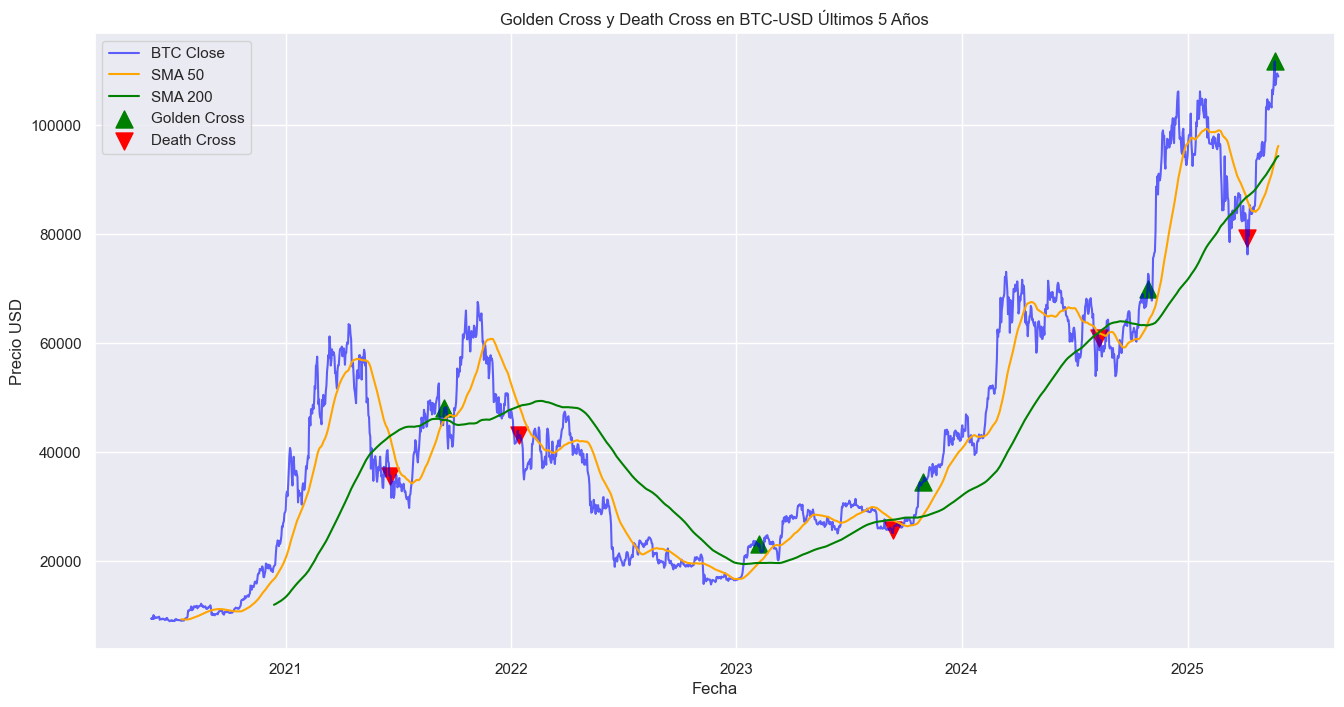

In [10]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# Descargar datos BTC últimos 5 años
btc = yf.download('BTC-USD', period='5y')

# Calcular medias móviles
btc['SMA50'] = btc['Close'].rolling(window=50).mean()
btc['SMA200'] = btc['Close'].rolling(window=200).mean()

# Detectar Golden Cross: SMA50 cruza hacia arriba SMA200
btc['GoldenCross'] = (btc['SMA50'] > btc['SMA200']) & (btc['SMA50'].shift(1) <= btc['SMA200'].shift(1))

# Detectar Death Cross: SMA50 cruza hacia abajo SMA200
btc['DeathCross'] = (btc['SMA50'] < btc['SMA200']) & (btc['SMA50'].shift(1) >= btc['SMA200'].shift(1))

# Plot
plt.figure(figsize=(16,8))
plt.plot(btc['Close'], label='BTC Close', color='blue', alpha=0.6)
plt.plot(btc['SMA50'], label='SMA 50', color='orange', linewidth=1.5)
plt.plot(btc['SMA200'], label='SMA 200', color='green', linewidth=1.5)

# Marcar Golden Cross con triángulo dorado
golden_crosses = btc[btc['GoldenCross']]
plt.scatter(golden_crosses.index, btc.loc[golden_crosses.index, 'Close'], 
            marker='^', color='green', s=150, label='Golden Cross')

# Marcar Death Cross con triángulo rojo hacia abajo
death_crosses = btc[btc['DeathCross']]
plt.scatter(death_crosses.index, btc.loc[death_crosses.index, 'Close'], 
            marker='v', color='red', s=150, label='Death Cross')

plt.title('Golden Cross y Death Cross en BTC-USD Últimos 5 Años')
plt.xlabel('Fecha')
plt.ylabel('Precio USD')
plt.legend()
plt.grid(True)
plt.show()

[*********************100%***********************]  1 of 1 completed


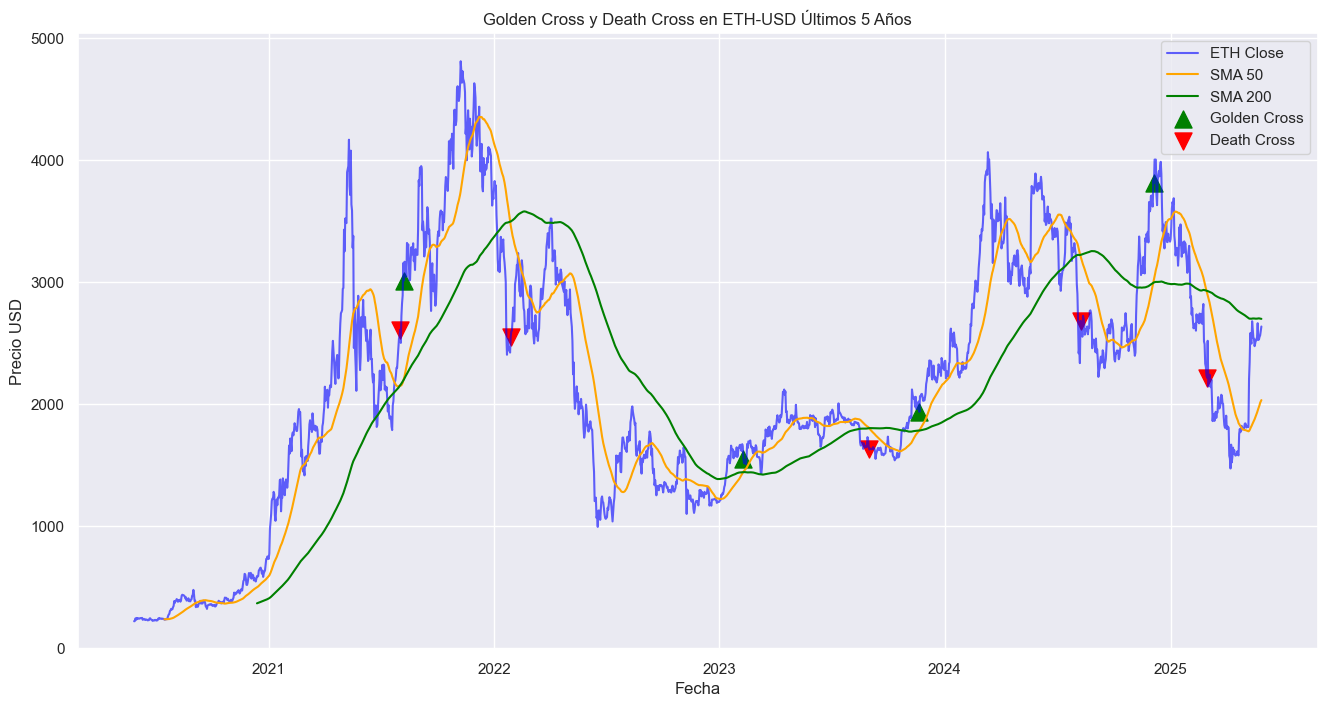

In [11]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# Descargar datos ETH últimos 5 años
eth = yf.download('ETH-USD', period='5y')

# Calcular medias móviles
eth['SMA50'] = eth['Close'].rolling(window=50).mean()
eth['SMA200'] = eth['Close'].rolling(window=200).mean()

# Detectar Golden Cross: SMA50 cruza hacia arriba SMA200
eth['GoldenCross'] = (eth['SMA50'] > eth['SMA200']) & (eth['SMA50'].shift(1) <= eth['SMA200'].shift(1))

# Detectar Death Cross: SMA50 cruza hacia abajo SMA200
eth['DeathCross'] = (eth['SMA50'] < eth['SMA200']) & (eth['SMA50'].shift(1) >= eth['SMA200'].shift(1))

# Plot
plt.figure(figsize=(16,8))
plt.plot(eth['Close'], label='ETH Close', color='blue', alpha=0.6)
plt.plot(eth['SMA50'], label='SMA 50', color='orange', linewidth=1.5)
plt.plot(eth['SMA200'], label='SMA 200', color='green', linewidth=1.5)

# Marcar Golden Cross con triángulo dorado
golden_crosses = eth[eth['GoldenCross']]
plt.scatter(golden_crosses.index, eth.loc[golden_crosses.index, 'Close'], 
            marker='^', color='green', s=150, label='Golden Cross')

# Marcar Death Cross con triángulo rojo hacia abajo
death_crosses = eth[eth['DeathCross']]
plt.scatter(death_crosses.index, eth.loc[death_crosses.index, 'Close'], 
            marker='v', color='red', s=150, label='Death Cross')

plt.title('Golden Cross y Death Cross en ETH-USD Últimos 5 Años')
plt.xlabel('Fecha')
plt.ylabel('Precio USD')
plt.legend()
plt.grid(True)
plt.show()

[*********************100%***********************]  1 of 1 completed


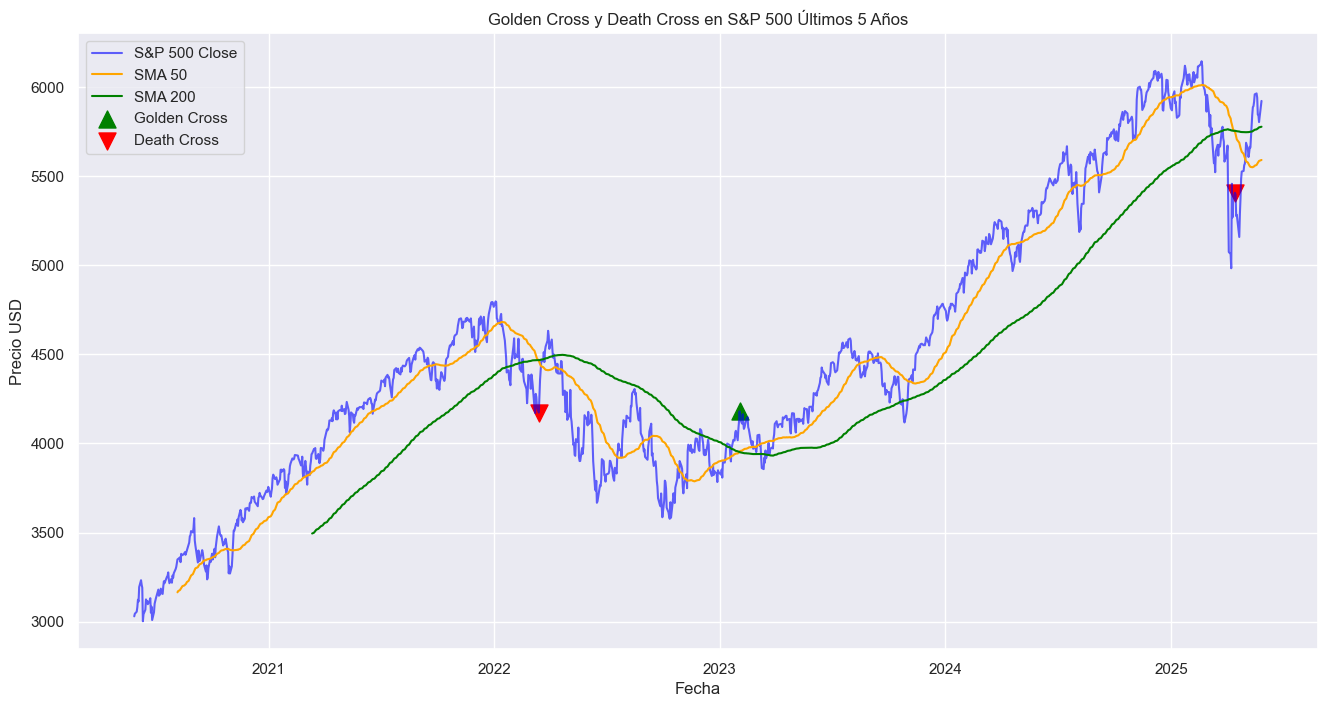

In [13]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# Descargar datos S&P 500 últimos 5 años
sp500 = yf.download('^GSPC', period='5y')

# Calcular medias móviles
sp500['SMA50'] = sp500['Close'].rolling(window=50).mean()
sp500['SMA200'] = sp500['Close'].rolling(window=200).mean()

# Detectar Golden Cross: SMA50 cruza hacia arriba SMA200
sp500['GoldenCross'] = (sp500['SMA50'] > sp500['SMA200']) & (sp500['SMA50'].shift(1) <= sp500['SMA200'].shift(1))

# Detectar Death Cross: SMA50 cruza hacia abajo SMA200
sp500['DeathCross'] = (sp500['SMA50'] < sp500['SMA200']) & (sp500['SMA50'].shift(1) >= sp500['SMA200'].shift(1))

# Plot
plt.figure(figsize=(16,8))
plt.plot(sp500['Close'], label='S&P 500 Close', color='blue', alpha=0.6)
plt.plot(sp500['SMA50'], label='SMA 50', color='orange', linewidth=1.5)
plt.plot(sp500['SMA200'], label='SMA 200', color='green', linewidth=1.5)

# Marcar Golden Cross con triángulo dorado
golden_crosses = sp500[sp500['GoldenCross']]
plt.scatter(golden_crosses.index, sp500.loc[golden_crosses.index, 'Close'], 
            marker='^', color='green', s=150, label='Golden Cross')

# Marcar Death Cross con triángulo rojo hacia abajo
death_crosses = sp500[sp500['DeathCross']]
plt.scatter(death_crosses.index, sp500.loc[death_crosses.index, 'Close'], 
            marker='v', color='red', s=150, label='Death Cross')

plt.title('Golden Cross y Death Cross en S&P 500 Últimos 5 Años')
plt.xlabel('Fecha')
plt.ylabel('Precio USD')
plt.legend()
plt.grid(True)
plt.show()